In [3]:
# CELL 1: Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn modules
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

In [4]:
# CELL 2: Load Data

# Loading the dataset with the correct separator
data = pd.read_csv('/Users/andreadario/Efrei/Semestre Malaysia 5/Intro to Machine Learning/Group Assignment-20251212/Assignment/data.csv', sep=';')

# Display first 5 rows
data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [5]:
# CELL 3: Data Overview

# Checking dataset shape and types
print("Shape of the dataset:", data.shape)
data.info()

Shape of the dataset: (4424, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's

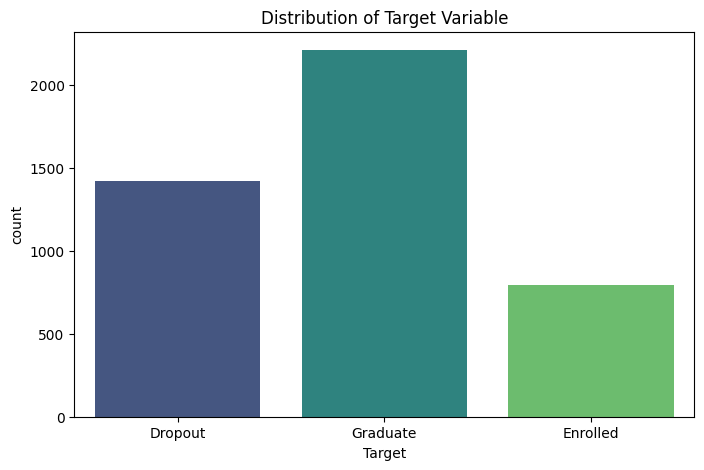

In [6]:
# CELL 4: Exploratory Data Analysis (EDA) - Target Distribution

# Visualizing the distribution of the target variable (Dropout, Graduate, Enrolled)
plt.figure(figsize=(8, 5))
sns.countplot(x='Target', data=data, palette='viridis')
plt.title('Distribution of Target Variable')
plt.show()

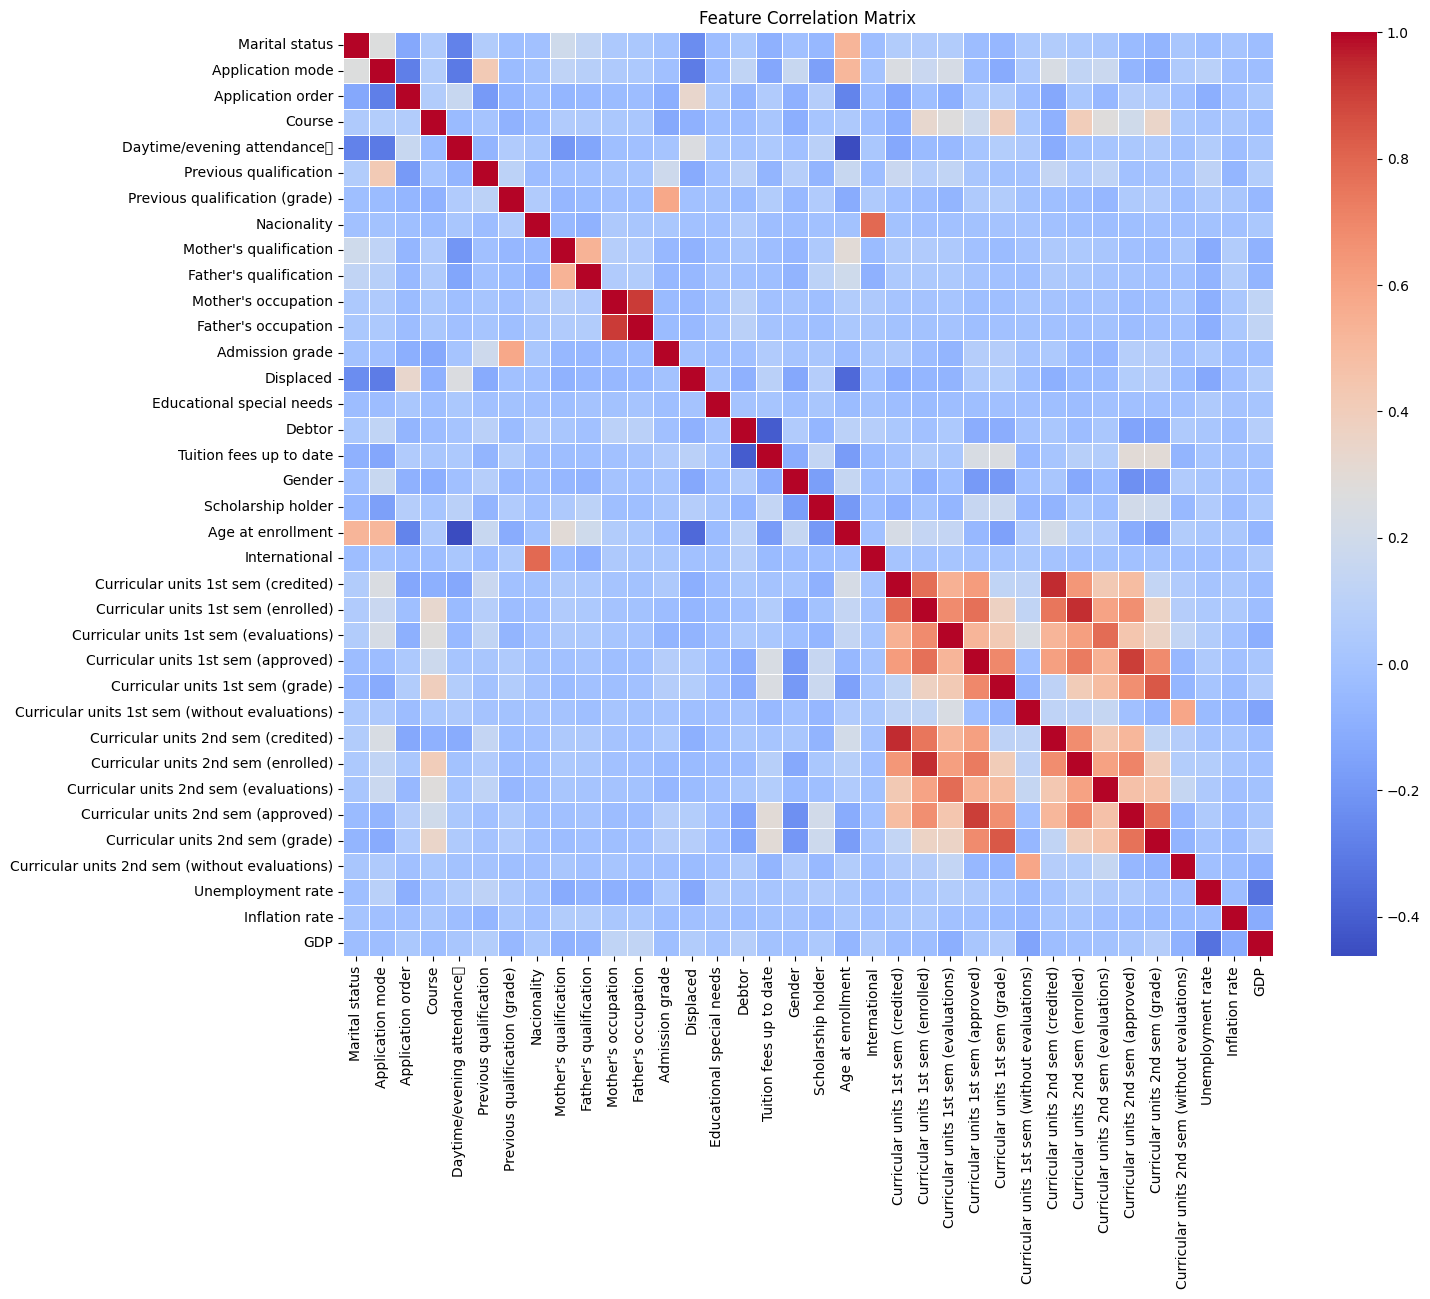

In [7]:
# CELL 5: EDA - Correlation Matrix

# Analyzing correlation between numerical features
plt.figure(figsize=(15, 12))
numerical_data = data.select_dtypes(include=[np.number])
sns.heatmap(numerical_data.corr(), cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

In [8]:
# CELL 6: Data Preprocessing

# Encoding the Target variable (categorical -> numerical)
le = LabelEncoder()
data['Target_Encoded'] = le.fit_transform(data['Target'])

print("Target Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# Defining Features (X) and Target (y)
X = data.drop(['Target', 'Target_Encoded'], axis=1)
y = data['Target_Encoded']

# Splitting data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# Feature Scaling (Standardization) - Essential for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Target Mapping: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}
Training set size: (3539, 36)
Test set size: (885, 36)


--- Training K-Nearest Neighbors (KNN) ---


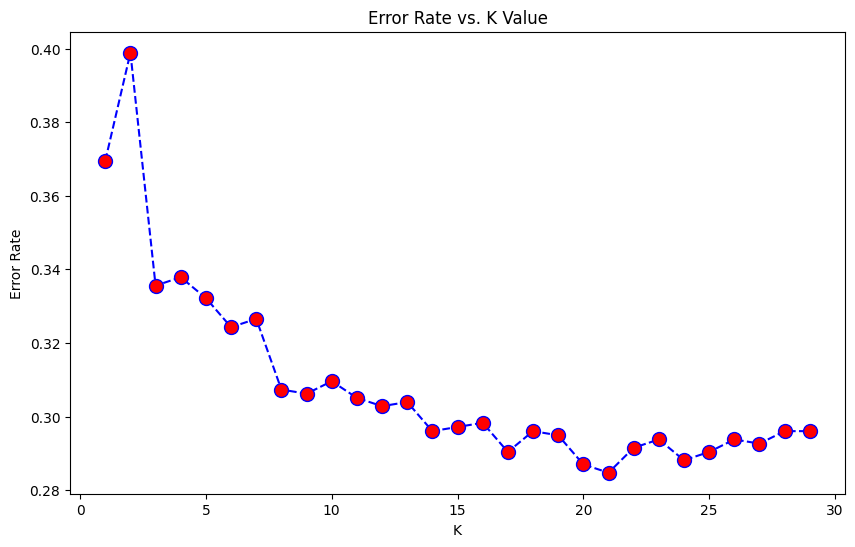

Best K value found: 21


In [9]:
# CELL 7: Model 1 Implementation - KNN

print("--- Training K-Nearest Neighbors (KNN) ---")

# Hyperparameter tuning to find the optimal 'k'
error_rate = []
for i in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    pred_i = knn.predict(X_test_scaled)
    error_rate.append(np.mean(pred_i != y_test))

# Plotting Error Rate vs K Value
plt.figure(figsize=(10, 6))
plt.plot(range(1, 30), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

# Using the best K (minimum error)
best_k = error_rate.index(min(error_rate)) + 1
print(f"Best K value found: {best_k}")

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

In [12]:
# CELL 8: Model 2 Implementation - Random Forest

print("--- Training Random Forest Classifier ---")

# Random Forest requires less tuning for a baseline, using 100 trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) # Using unscaled data (Trees don't require scaling)
y_pred_rf = rf_model.predict(X_test)

from sklearn.model_selection import cross_val_score
# 5-fold Cross Validation
scores = cross_val_score(rf_model, X, y, cv=5)
print(f"Cross-Validation Scores: {scores}")
print(f"Average Accuracy: {scores.mean():.4f}")


--- Training Random Forest Classifier ---
Cross-Validation Scores: [0.76949153 0.77062147 0.78757062 0.78079096 0.76696833]
Average Accuracy: 0.7751



Evaluation: K-Nearest Neighbors
Accuracy: 0.7152542372881356

Classification Report:
               precision    recall  f1-score   support

     Dropout       0.84      0.63      0.72       284
    Enrolled       0.51      0.19      0.28       159
    Graduate       0.69      0.96      0.80       442

    accuracy                           0.72       885
   macro avg       0.68      0.59      0.60       885
weighted avg       0.71      0.72      0.68       885



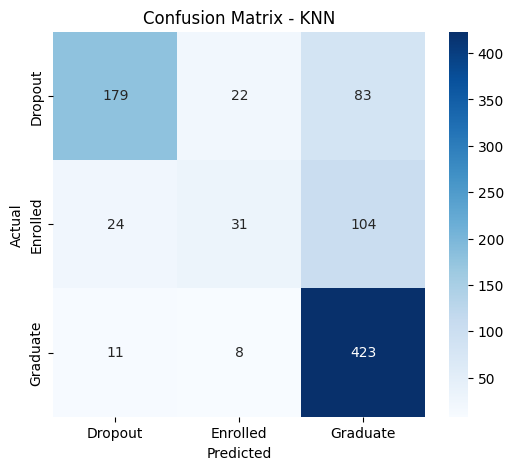


Evaluation: Random Forest
Accuracy: 0.7706214689265537

Classification Report:
               precision    recall  f1-score   support

     Dropout       0.81      0.75      0.78       284
    Enrolled       0.58      0.38      0.46       159
    Graduate       0.79      0.93      0.85       442

    accuracy                           0.77       885
   macro avg       0.73      0.68      0.70       885
weighted avg       0.76      0.77      0.76       885



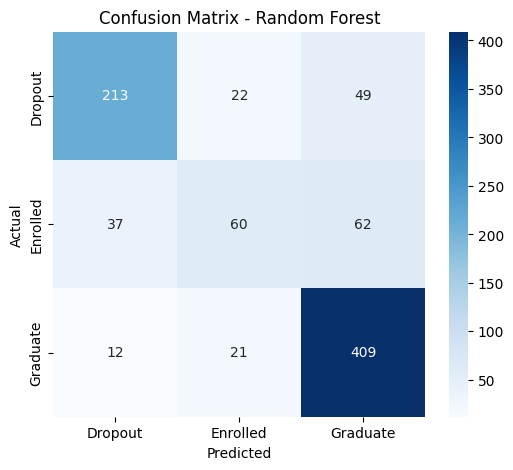


Final Comparison:
KNN Accuracy: 0.7153
Random Forest Accuracy: 0.7706
Conclusion: Random Forest performs better on this dataset.


In [13]:
# CELL 9: Model Evaluation & Comparison

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# 1. Evaluate KNN
print("\nEvaluation: K-Nearest Neighbors")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn, target_names=le.classes_))
plot_confusion_matrix(y_test, y_pred_knn, "Confusion Matrix - KNN")

# 2. Evaluate Random Forest
print("\nEvaluation: Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, target_names=le.classes_))
plot_confusion_matrix(y_test, y_pred_rf, "Confusion Matrix - Random Forest")

# 3. Final Comparison
acc_knn = accuracy_score(y_test, y_pred_knn)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"\nFinal Comparison:")
print(f"KNN Accuracy: {acc_knn:.4f}")
print(f"Random Forest Accuracy: {acc_rf:.4f}")

if acc_rf > acc_knn:
    print("Conclusion: Random Forest performs better on this dataset.")
else:
    print("Conclusion: KNN performs better on this dataset.")